# Near-Earth Asteroid Analysis

This notebook analyzes near-earth asteroid data using **NumPy** for data processing and **Matplotlib** for visualization.

We'll explore two datasets:
1. **Near-Earth Asteroids (2025)** — orbital and physical characteristics of known NEAs
2. **Close Approaches (2015–2035)** — records of asteroids making close approaches to Earth

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set a nice style
plt.style.use('seaborn-v0_8-darkgrid')

# Make figures look better
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
})

def _to_float_safe(arr):
    """Convert string array to float, using NaN for empty/invalid entries."""
    result = np.full(len(arr), np.nan)
    for i, v in enumerate(arr):
        v = v.strip()
        if v == '' or v == '--':
            continue
        try:
            result[i] = float(v)
        except ValueError:
            pass
    return result

print('✅ NumPy version:', np.__version__)
print('✅ Matplotlib version:', plt.matplotlib.__version__)

✅ NumPy version: 2.5.1
✅ Matplotlib version: 3.11.1


---
## 1. Load the Data

We'll use `np.genfromtxt` to load both CSV files. Because the files contain mixed data types (strings, floats, booleans), we'll use structured arrays with specified dtypes.

In [2]:
# ── Near-Earth Asteroids ──────────────────────────────────────────────────
# Load everything as strings, then convert numeric columns manually

# Read the raw CSV lines with Python to avoid dtype auto-detection issues
with open('input/near_earth_asteroids_2025.csv', 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')
    nea_rows = []
    for line in f:
        row = line.strip().split(',')
        nea_rows.append(row)

# Build dictionary from columns
nea_data = {}
for idx, col in enumerate(header):
    col_strip = col.strip()
    raw_col = np.array([str(r[idx]).strip() if idx < len(r) else '' for r in nea_rows], dtype=object)
    float_col = _to_float_safe(raw_col)
    if np.any(~np.isnan(float_col)):
        nea_data[col_strip] = float_col
    else:
        nea_data[col_strip] = raw_col

print(f'Loaded {len(nea_rows)} near-earth asteroids')
print(f'Column names: {header}')
print(f'diameter_km dtype: {nea_data["diameter_km"].dtype}, sample: {nea_data["diameter_km"][:3]}')

Loaded 41281 near-earth asteroids
Column names: ['spkid', 'full_name', 'pdes', 'name', 'pha', 'H', 'diameter_km', 'diameter_m', 'diameter_is_estimated', 'size_category', 'albedo', 'rot_per', 'class', 'e', 'a', 'i', 'q', 'ad', 'per', 'per_y', 'moid_au', 'moid_km', 'moid_lunar_distances', 'n', 'condition_code', 'first_obs', 'last_obs', 'data_arc', 'data_arc_years']
diameter_km dtype: float64, sample: [16.84        2.70682989  4.2       ]


In [3]:
# ── Close Approaches ──────────────────────────────────────────────────────

with open('input/asteroid_close_approaches_2015_2035.csv', 'r', encoding='utf-8') as f:
    ca_header = f.readline().strip().split(',')
    ca_rows = []
    for line in f:
        row = line.strip().split(',')
        ca_rows.append(row)

# Build dictionary from columns
ca_data = {}
for idx, col in enumerate(ca_header):
    col_strip = col.strip()
    raw_col = np.array([str(r[idx]).strip() if idx < len(r) else '' for r in ca_rows], dtype=object)
    float_col = _to_float_safe(raw_col)
    if np.any(~np.isnan(float_col)):
        ca_data[col_strip] = float_col
    else:
        ca_data[col_strip] = raw_col

print(f'Loaded {len(ca_rows)} close-approach records')
print(f'Column names: {ca_header}')

Loaded 27430 close-approach records
Column names: ['designation', 'full_name', 'close_approach_date', 'distance_au', 'dist_km', 'dist_lunar', 'distance_min_au', 'distance_max_au', 'velocity_km_s', 'v_rel_kmh', 'velocity_infinity_km_s', 'absolute_magnitude', 'is_future']


---
## 2. Near-Earth Asteroids — Diameter Histogram

Let's look at the distribution of asteroid diameters. Most asteroids are small, with a long tail of larger bodies.

Diameter range: 0.00 – 37.67 km
Mean diameter: 0.17 km
Median diameter: 0.06 km


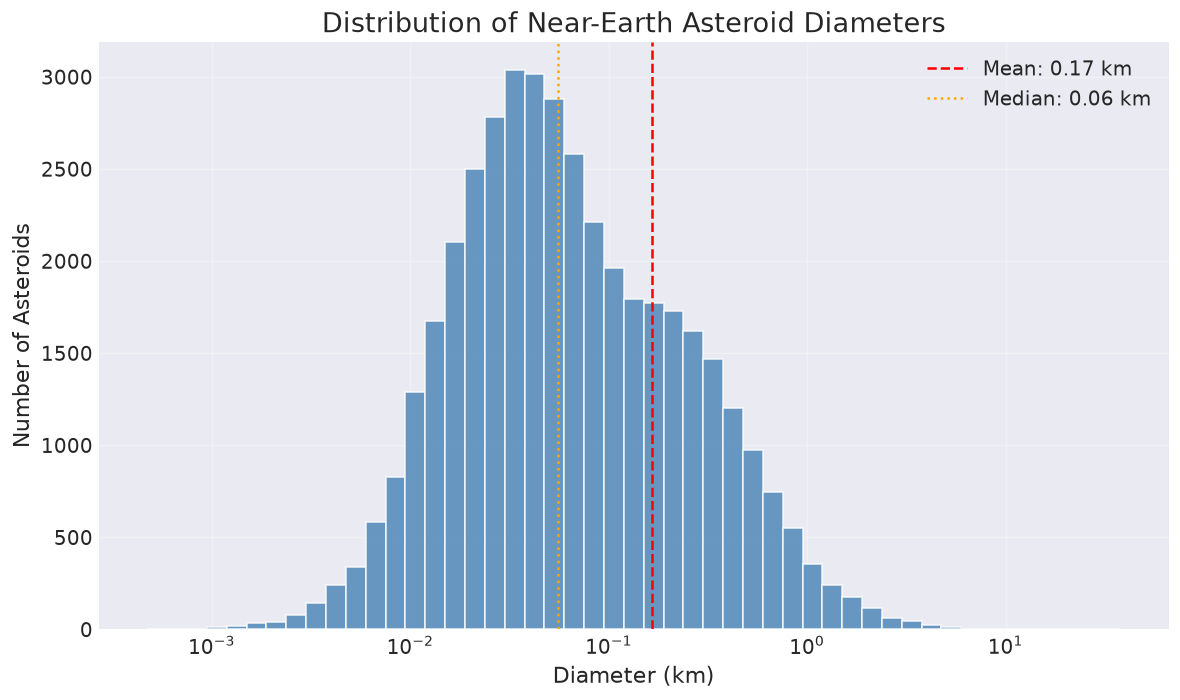

In [4]:
# Extract diameters (km) — filter out NaN/masked values
diameters = nea_data['diameter_km']
diameters = diameters[~np.isnan(diameters)]

print(f'Diameter range: {diameters.min():.2f} – {diameters.max():.2f} km')
print(f'Mean diameter: {diameters.mean():.2f} km')
print(f'Median diameter: {np.median(diameters):.2f} km')

fig, ax = plt.subplots()

# Log-scale bins work well for skewed distributions
bins = np.logspace(np.log10(diameters.min()), np.log10(diameters.max()), 50)
ax.hist(diameters, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xscale('log')
ax.set_xlabel('Diameter (km)')
ax.set_ylabel('Number of Asteroids')
ax.set_title('Distribution of Near-Earth Asteroid Diameters')
ax.grid(True, alpha=0.3)

# Annotate stats
ax.axvline(diameters.mean(), color='red', ls='--', lw=1.5, label=f'Mean: {diameters.mean():.2f} km')
ax.axvline(np.median(diameters), color='orange', ls=':', lw=1.5, label=f'Median: {np.median(diameters):.2f} km')
ax.legend()

plt.tight_layout()
plt.savefig('output/nea_diameter_histogram.png', dpi=150)
plt.show()

---
## 3. Orbital Classes — Bar Chart

Asteroids are classified by their orbital characteristics. Common classes include:
- **AMO** (Amor): orbits outside Earth's but inside Mars'
- **APO** (Apollo): cross Earth's orbit
- **ATE** (Aten): orbits mostly inside Earth's
- **IEO** (Inner-Earth Objects): orbits entirely inside Earth's

Orbital class distribution:
  APO: 23484 (56.9%)
  AMO: 14408 (34.9%)
  ATE: 3351 (8.1%)
  IEO: 38 (0.1%)


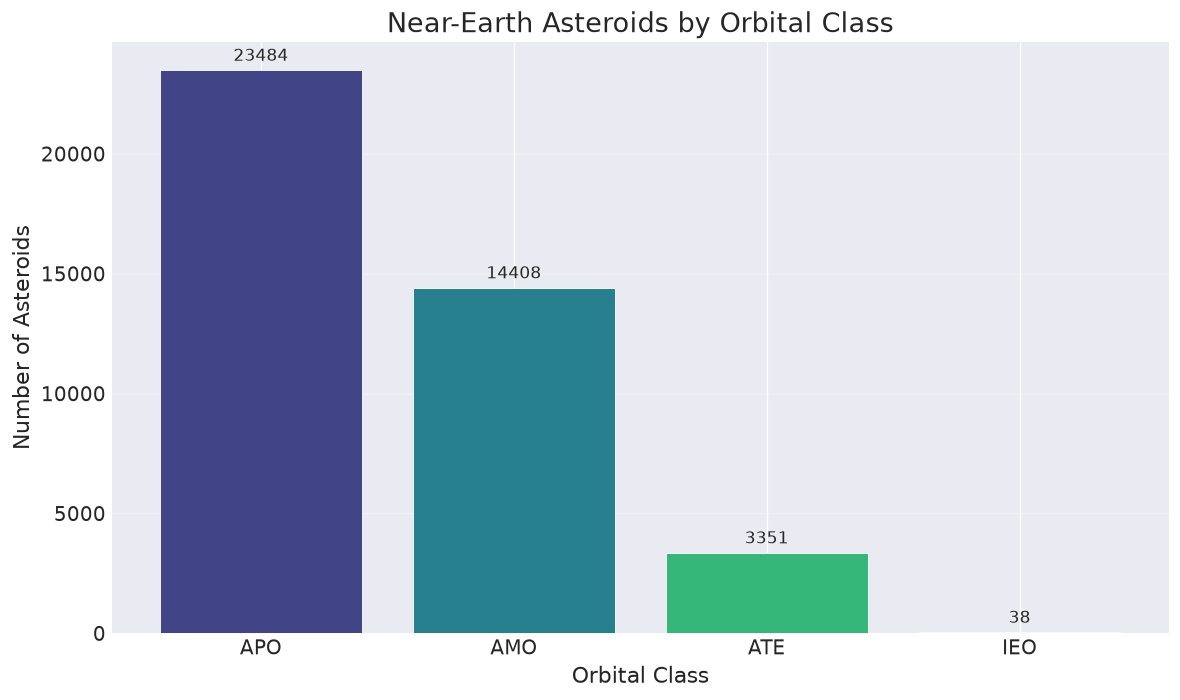

In [5]:
# Count occurrences of each orbital class
classes = nea_data['class']
unique_classes, counts = np.unique(classes, return_counts=True)

# Sort by count descending
sort_idx = np.argsort(counts)[::-1]
unique_classes = unique_classes[sort_idx]
counts = counts[sort_idx]

print('Orbital class distribution:')
for cls, cnt in zip(unique_classes, counts):
    print(f'  {cls}: {cnt} ({100*cnt/len(classes):.1f}%)')

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(unique_classes)))

bars = ax.bar(unique_classes, counts, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Orbital Class')
ax.set_ylabel('Number of Asteroids')
ax.set_title('Near-Earth Asteroids by Orbital Class')

# Add count labels on bars
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
            str(cnt), ha='center', va='bottom', fontsize=10)

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output/nea_orbital_classes.png', dpi=150)
plt.show()

---
## 4. Diameter vs. Eccentricity — Scatter Plot

Let's see if there's a relationship between asteroid size and orbital eccentricity, and whether potentially hazardous asteroids (PHAs) differ from the rest.

Potentially hazardous: 2539
Non-hazardous: 38742


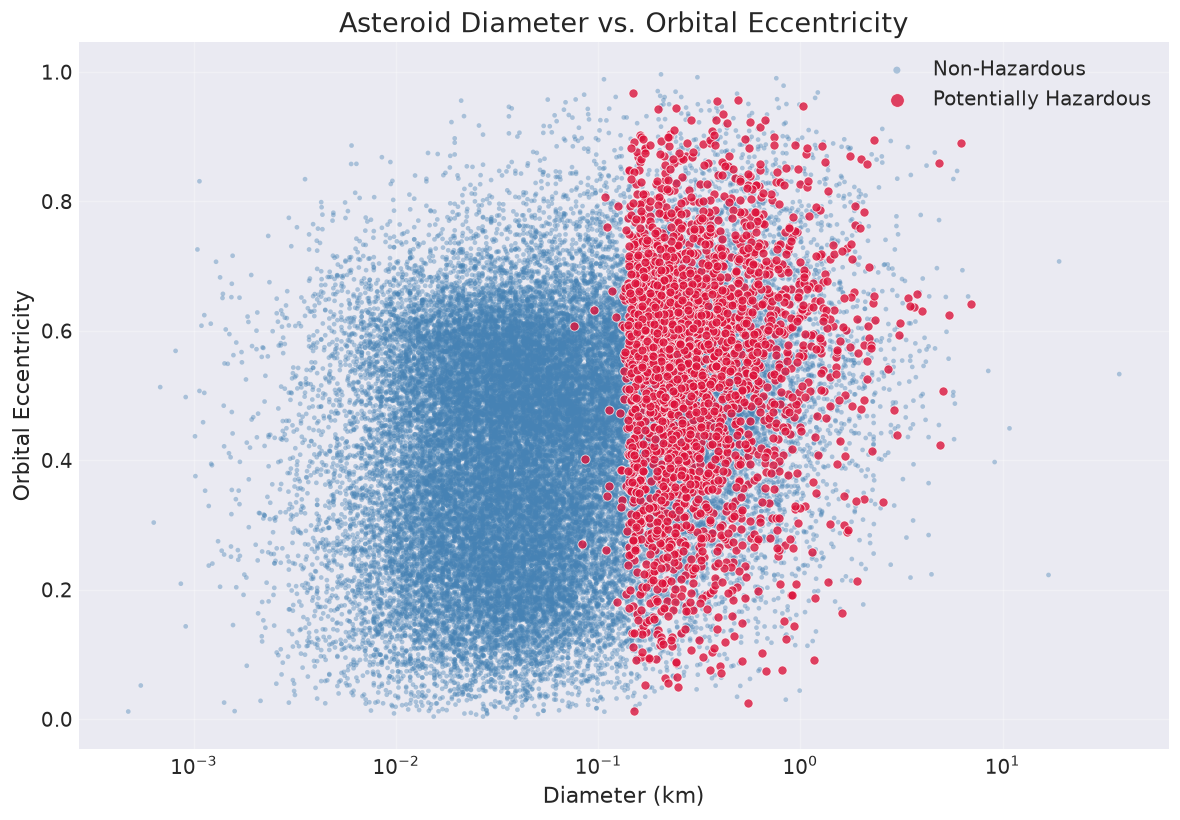

In [6]:
# Extract columns
diam = nea_data['diameter_km']
ecc = nea_data['e']
pha_str = nea_data['pha']  # 'True' / 'False' strings

# Filter valid (non-NaN) entries
valid = ~(np.isnan(diam) | np.isnan(ecc))
diam = diam[valid]
ecc = ecc[valid]
pha_str = pha_str[valid]

# Convert 'pha' string to boolean mask
pha_mask = pha_str == 'True'

print(f'Potentially hazardous: {pha_mask.sum()}')
print(f'Non-hazardous: {(~pha_mask).sum()}')

fig, ax = plt.subplots(figsize=(10, 7))

# Non-hazardous (light)
ax.scatter(diam[~pha_mask], ecc[~pha_mask],
           alpha=0.4, s=8, c='steelblue', label='Non-Hazardous', edgecolors='none')

# Potentially hazardous (highlighted)
ax.scatter(diam[pha_mask], ecc[pha_mask],
           alpha=0.8, s=30, c='crimson', label='Potentially Hazardous',
           edgecolors='white', linewidth=0.5)

ax.set_xscale('log')
ax.set_xlabel('Diameter (km)')
ax.set_ylabel('Orbital Eccentricity')
ax.set_title('Asteroid Diameter vs. Orbital Eccentricity')
ax.legend(markerscale=1.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/nea_diameter_vs_eccentricity.png', dpi=150)
plt.show()

---
## 5. Potentially Hazardous Asteroids — Pie Chart

What fraction of known NEAs are classified as potentially hazardous?

Potentially Hazardous: 2539 (6.15%)
Non-Hazardous:        38742 (93.85%)


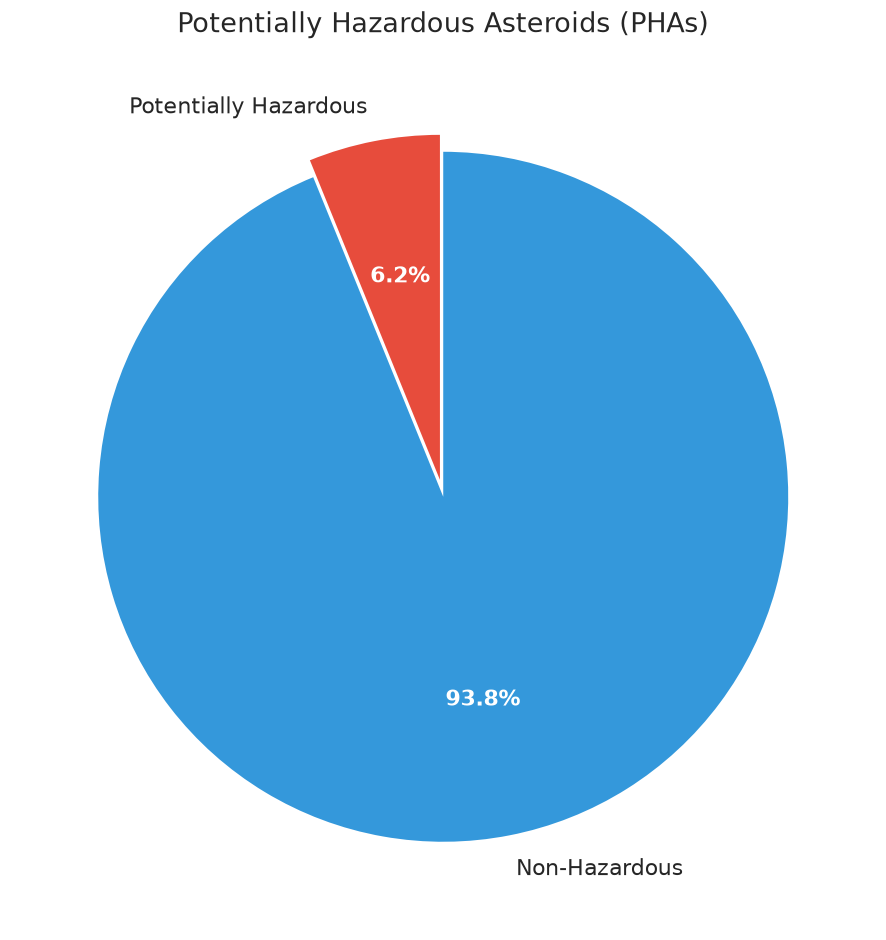

In [7]:
pha_all = nea_data['pha']
n_pha = (pha_all == 'True').sum()
n_non = (pha_all == 'False').sum()

print(f'Potentially Hazardous: {n_pha} ({100*n_pha/len(pha_all):.2f}%)')
print(f'Non-Hazardous:        {n_non} ({100*n_non/len(pha_all):.2f}%)')

fig, ax = plt.subplots(figsize=(8, 8))

colors_pie = ['#e74c3c', '#3498db']
wedge, texts, autotexts = ax.pie(
    [n_pha, n_non],
    labels=['Potentially Hazardous', 'Non-Hazardous'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_pie,
    explode=(0.05, 0),
    shadow=False,
    textprops={'fontsize': 13}
)

# Make the percentage text more readable
for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')

ax.set_title('Potentially Hazardous Asteroids (PHAs)', fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('output/nea_pha_pie_chart.png', dpi=150)
plt.show()

---
## 6. Close Approaches — Distance Histogram

Now let's explore the close-approaches dataset. How close do these asteroids come to Earth?

Distance range: 6,599 – 14,958,783 km
Mean distance: 6,472,706 km
Median distance: 5,905,320 km


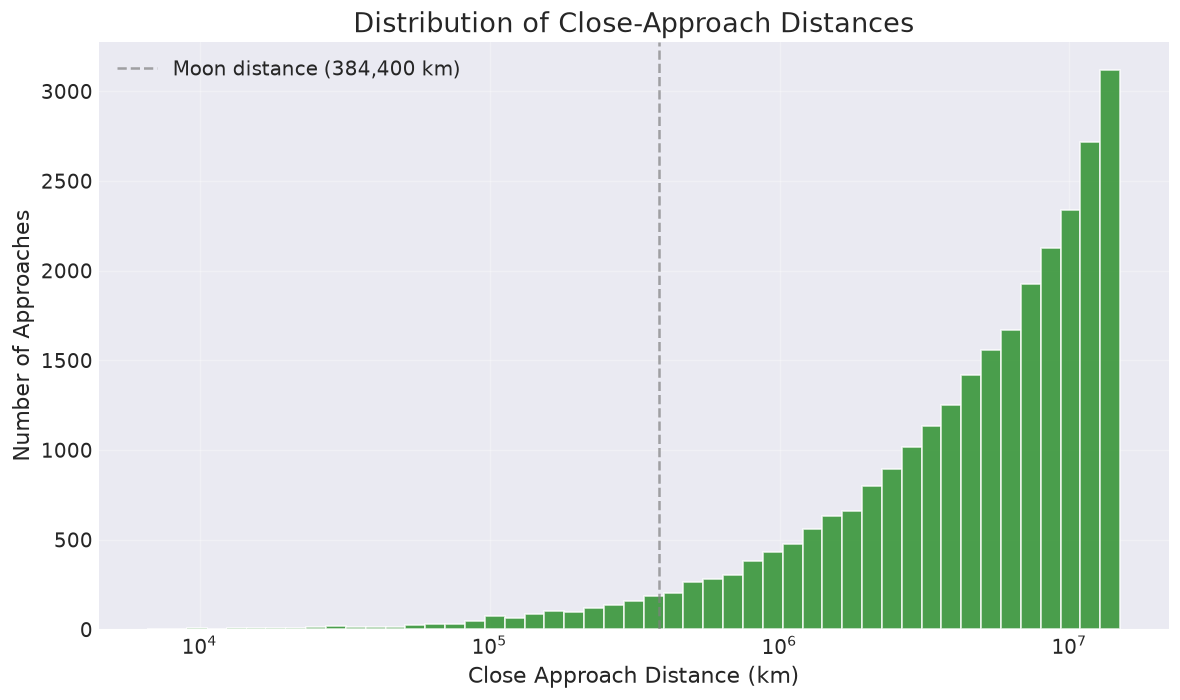

In [8]:
# Extract distances in km
dist_km = ca_data['dist_km']
dist_km = dist_km[~np.isnan(dist_km)]

print(f'Distance range: {dist_km.min():,.0f} – {dist_km.max():,.0f} km')
print(f'Mean distance: {dist_km.mean():,.0f} km')
print(f'Median distance: {np.median(dist_km):,.0f} km')

fig, ax = plt.subplots(figsize=(10, 6))

# Log-scale histogram since distances span many orders of magnitude
bins = np.logspace(np.log10(dist_km.min()), np.log10(dist_km.max()), 50)
ax.hist(dist_km, bins=bins, color='forestgreen', edgecolor='white', alpha=0.8)
ax.set_xscale('log')
ax.set_xlabel('Close Approach Distance (km)')
ax.set_ylabel('Number of Approaches')
ax.set_title('Distribution of Close-Approach Distances')
ax.grid(True, alpha=0.3)

# Reference line: distance to the Moon (~384,400 km)
ax.axvline(384400, color='gray', ls='--', lw=1.5, alpha=0.7, label='Moon distance (384,400 km)')
ax.legend()

plt.tight_layout()
plt.savefig('output/ca_distance_histogram.png', dpi=150)
plt.show()

---
## 7. Close Approaches — Velocity Histogram

How fast are these asteroids moving relative to Earth?

Velocity range: 0.1 – 40.2 km/s
Mean velocity: 10.6 km/s
Median velocity: 9.5 km/s


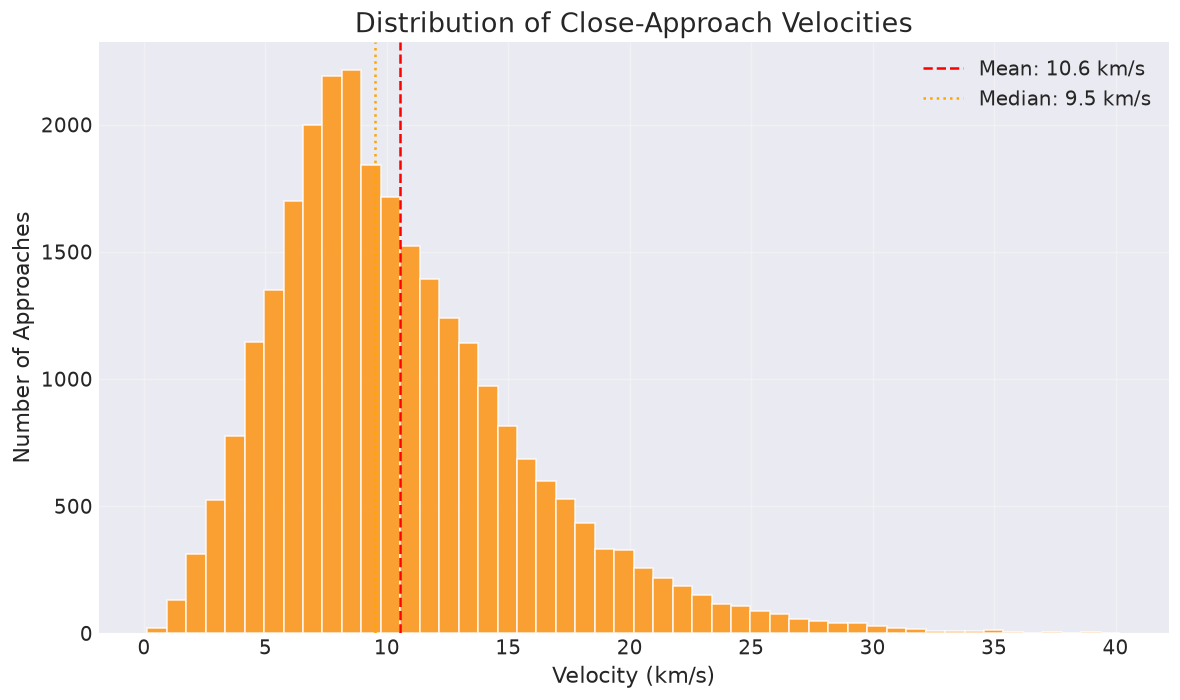

In [9]:
vel = ca_data['velocity_km_s']
vel = vel[~np.isnan(vel)]

print(f'Velocity range: {vel.min():.1f} – {vel.max():.1f} km/s')
print(f'Mean velocity: {vel.mean():.1f} km/s')
print(f'Median velocity: {np.median(vel):.1f} km/s')

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(vel, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
ax.set_xlabel('Velocity (km/s)')
ax.set_ylabel('Number of Approaches')
ax.set_title('Distribution of Close-Approach Velocities')
ax.grid(True, alpha=0.3)

# Stats annotations
ax.axvline(vel.mean(), color='red', ls='--', lw=1.5, label=f'Mean: {vel.mean():.1f} km/s')
ax.axvline(np.median(vel), color='orange', ls=':', lw=1.5, label=f'Median: {np.median(vel):.1f} km/s')
ax.legend()

plt.tight_layout()
plt.savefig('output/ca_velocity_histogram.png', dpi=150)
plt.show()

---
## 8. Velocity vs. Distance — Scatter Plot

Is there a correlation between how fast an asteroid is moving and how close it gets to Earth?

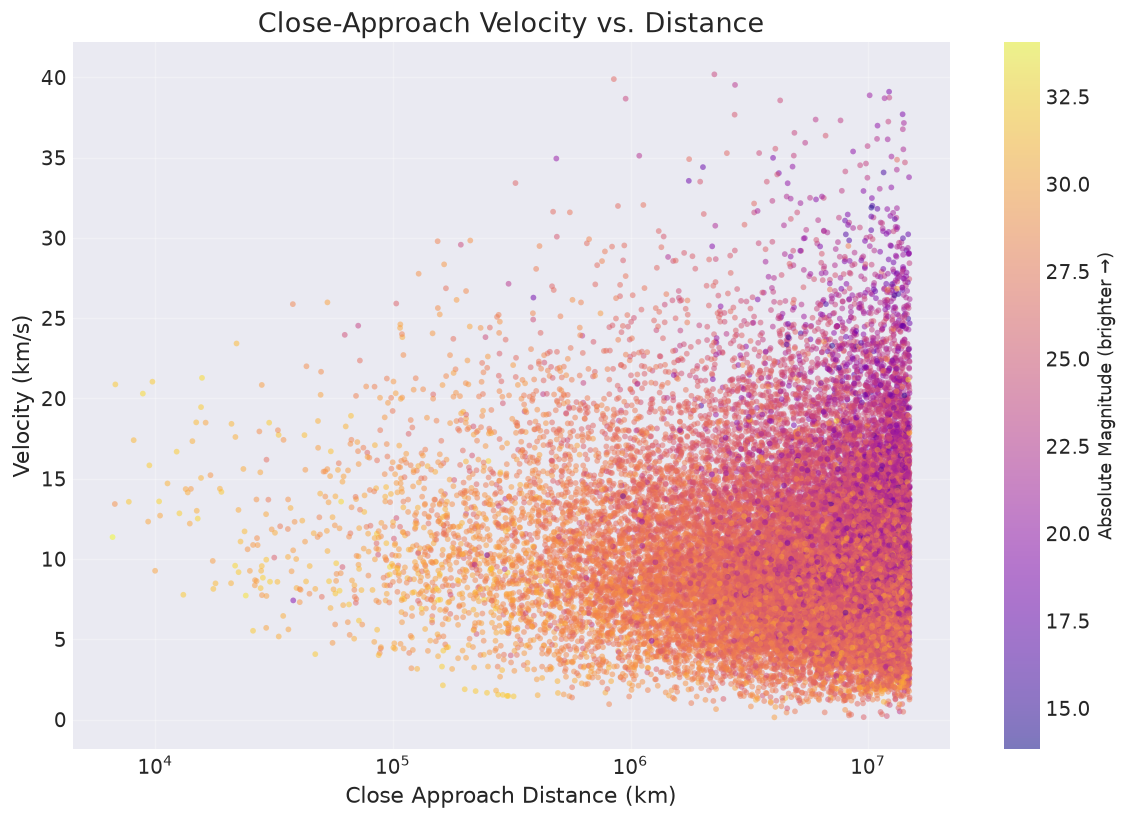

In [10]:
vel_all = ca_data['velocity_km_s']
dist_all = ca_data['dist_km']

# Filter valid entries
valid_ca = ~(np.isnan(vel_all) | np.isnan(dist_all))
vel_all = vel_all[valid_ca]
dist_all = dist_all[valid_ca]

# Also get absolute magnitude for color coding
mag = ca_data['absolute_magnitude'][valid_ca]

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(dist_all, vel_all, c=mag, cmap='plasma',
                alpha=0.5, s=12, edgecolors='none')

ax.set_xscale('log')
ax.set_xlabel('Close Approach Distance (km)')
ax.set_ylabel('Velocity (km/s)')
ax.set_title('Close-Approach Velocity vs. Distance')
ax.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Absolute Magnitude (brighter →)', fontsize=11)

plt.tight_layout()
plt.savefig('output/ca_velocity_vs_distance.png', dpi=150)
plt.show()

---
## 9. Close Approaches Over Time

Let's see how the number and distances of close approaches vary from 2015 to 2035.

/tmp/ipykernel_53464/788820535.py:6: DeprecationWarning: The chararray class is deprecated and will be removed in a future release. Use an ndarray with a string or bytes dtype instead.
  years = np.char.array(date_strs).astype('U10')  # take first 10 chars: 'YYYY-MM-DD'


Data spans 2015 – 2035
Total valid records: 27430


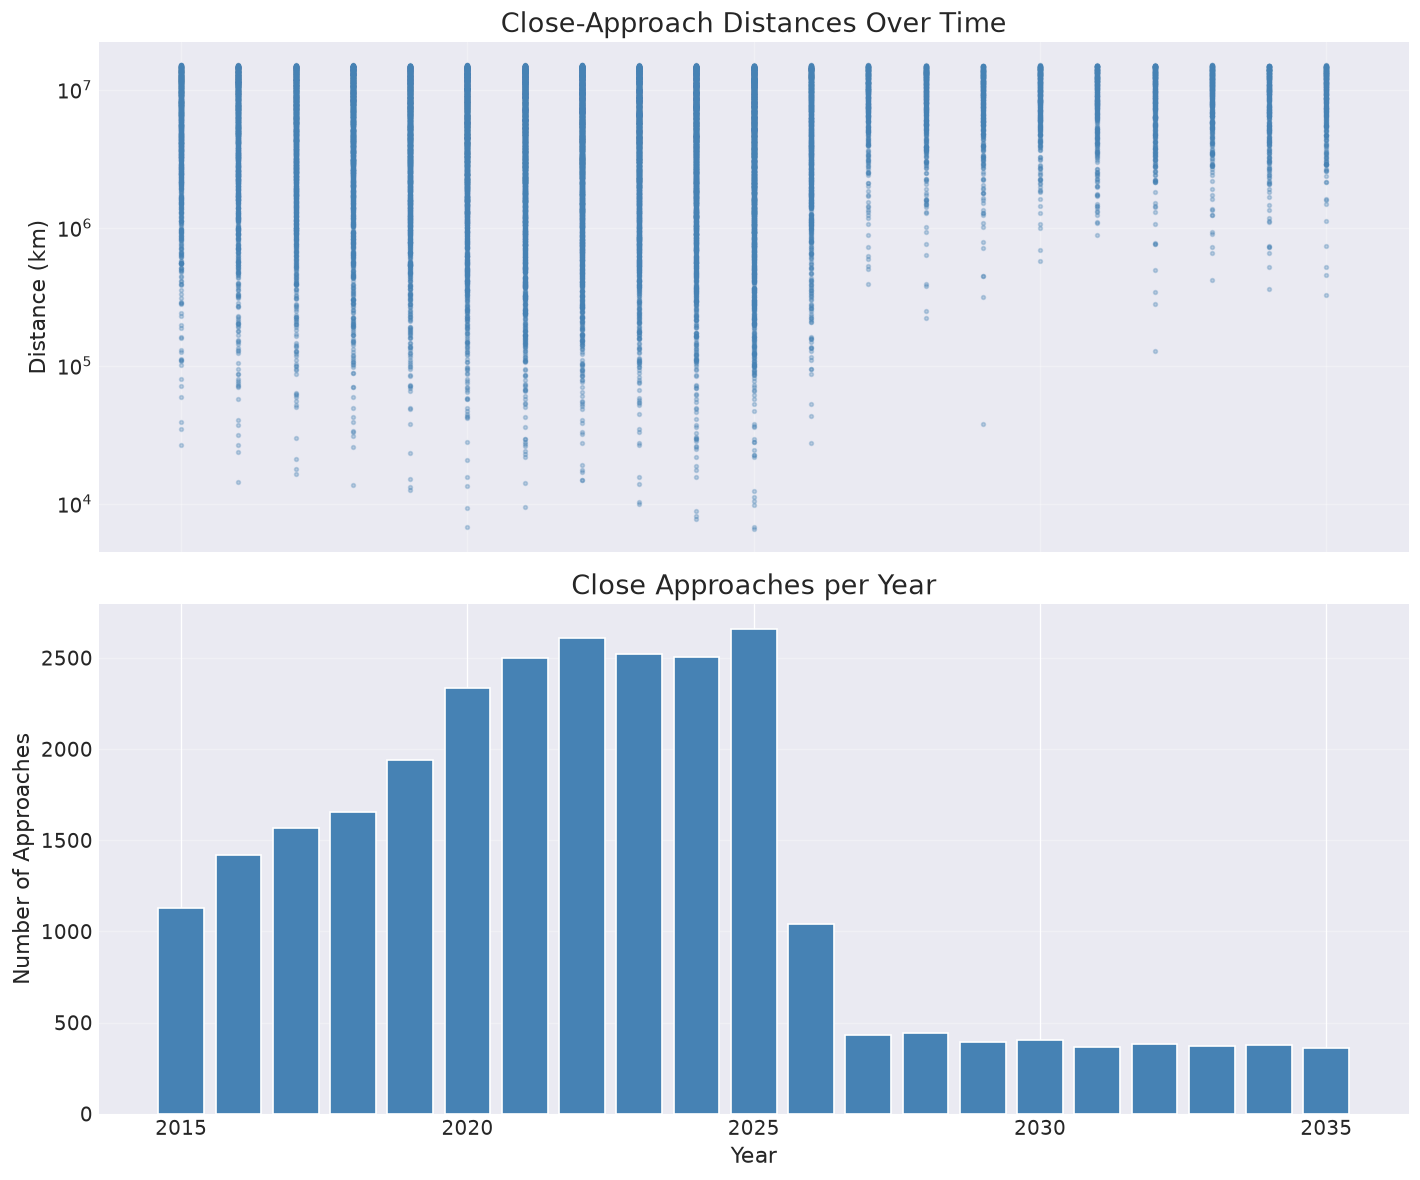

In [11]:
# Parse close_approach_date — extract year
# The dates are in format 'YYYY-MM-DD HH:MM'
date_strs = ca_data['close_approach_date']

# Extract year as integer using simple array comprehension
years_float = np.array([int(str(y).strip()[:4]) for y in date_strs], dtype=float)

dist_for_time = ca_data['dist_km']
vel_for_time = ca_data['velocity_km_s']

valid_t = ~(np.isnan(dist_for_time) | np.isnan(vel_for_time))
years_float = years_float[valid_t]
dist_for_time = dist_for_time[valid_t]
vel_for_time = vel_for_time[valid_t]

print(f'Data spans {int(years_float.min())} – {int(years_float.max())}')
print(f'Total valid records: {len(years_float)}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ── Top: Distance over time ──
ax1.scatter(years_float, dist_for_time, alpha=0.3, s=5, c='steelblue')
ax1.set_yscale('log')
ax1.set_ylabel('Distance (km)')
ax1.set_title('Close-Approach Distances Over Time')
ax1.grid(True, alpha=0.3)

# ── Bottom: Approaches per year ──
year_bins = np.arange(int(years_float.min()), int(years_float.max()) + 2) - 0.5
counts_per_year, _ = np.histogram(years_float, bins=year_bins)
year_centers = np.arange(int(years_float.min()), int(years_float.max()) + 1)

ax2.bar(year_centers, counts_per_year, color='steelblue', edgecolor='white', width=0.8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Approaches')
ax2.set_title('Close Approaches per Year')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/ca_time_series.png', dpi=150)
plt.show()

---
## Summary

Key observations from this analysis:

1. **Asteroid sizes** follow a heavily skewed distribution — most NEAs are small (< 1 km), with a few giants.
2. **Orbital classes** are dominated by Apollo (Earth-crossing) and Amor (Mars-crossing) asteroids.
3. **Potentially hazardous asteroids** make up a small fraction of the total, but tend to have more eccentric orbits.
4. **Close-approach distances** vary widely, with many passing well beyond the Moon's orbit.
5. **Approach velocities** average around 10–20 km/s, with a broad distribution.
6. **Future observations** (2025–2035) show many more predicted approaches, reflecting improved detection and cataloging.